# Día 3: clasificación de `dedo` con modelos fundacionales

## Objetivo

En este cuaderno vais a explorar dos usos distintos de modelos fundacionales para resolver la tarea `dedo`:

- clasificación multimodal zero-shot mediante prompting;
- extracción de embeddings visuales con un encoder preentrenado y entrenamiento de un clasificador sencillo encima.

La meta no es encontrar una única solución correcta, sino comparar qué se puede conseguir:

- sin entrenar un modelo sobre vuestras clases;
- reutilizando representaciones visuales ya aprendidas.

## Interpretación del problema

En este dataset:

- `si` significa postura correcta;
- `no` significa postura incorrecta.

Antes de escribir prompts o extraer embeddings, aseguraos de que todos en el grupo compartís una definición visual clara de ambas clases.

## Posibles caminos

Hoy podéis llegar por varios sitios:

- prompting zero-shot puro;
- prompting con unas pocas referencias visuales;
- embeddings de un encoder visual y un clasificador lineal;
- comparar imagen completa frente a panel recortado.

No hace falta llegar a todas las partes. Es perfectamente válido completar bien una y dejar la otra como ampliación.

## Instalación

```bash
pip install openai google-genai python-dotenv pandas scikit-learn seaborn matplotlib tqdm pillow timm torch torchvision opencv-python
```

## Claves API

Si vais a usar prompting multimodal, preparad un archivo `.env` con las claves que tengáis disponibles.

```text
OPENROUTER_API_KEY=sk-or-...
GROQ_API_KEY=gsk_...
GEMINI_API_KEY=AIza...
```

No hace falta que funcionen todos los providers. Con uno basta para la práctica.

## Importaciones

In [147]:
import base64
import io
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tenacity import (
    retry,
    retry_if_exception_type,
    stop_after_attempt,
    wait_exponential,
)
from tqdm.auto import tqdm

load_dotenv()
pd.options.display.max_colwidth = None
print("OpenRouter:", os.environ["OPENROUTER_API_KEY"][:6])

OpenRouter: sk-or-


## Configuración general

Decidid aquí:

- ruta del dataset;
- semilla aleatoria;
- tamaño de test;
- provider o providers activos;
- modelo multimodal elegido;
- encoder visual si hacéis embeddings.

In [148]:
# Define aquí la configuración general.
DATA_DIR = Path("/home/manel31/Escritorio/cursoIA/dedo") 

SEED = 42
TEST_SIZE = 0.2

DEFAULT_OPENROUTER_MODEL = "~google/gemini-flash-latest"

#Configuracion Tenacity
MAX_RETRIES = 5
WAIT_MIN    = 2   # segundos
WAIT_MAX    = 30  # segundos

#Encoder visual para embeddings
DINO_MODEL_NAME = "vit_small_patch14_dinov2.lvd142m"

#El prompting
N_PROMPTING = 30

print(DATA_DIR.exists())


True


In [149]:
#Inicializar cliente OpenROuter
openrouter_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

## Cargar el dataset `dedo`

Igual que en los días anteriores, empezad por una tabla con rutas y etiquetas.

In [150]:
# Crea aquí un DataFrame con las imágenes y sus etiquetas.
def load_dedo_dataset(data_dir: Path) -> pd.DataFrame:
    """Carga imágenes del dataset dedo en un DataFrame."""
    rows = []
    label_map = {"si": "si", "no": "no"}

    for label_name, label_str in label_map.items():
        folder = data_dir / label_name
        if not folder.exists():
            print(f"[AVISO] No se encuentra la carpeta: {folder}")
            continue
        for img_path in sorted(folder.iterdir()):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}:
                rows.append(
                    {
                        "path": img_path,
                        "label": label_str,
                        "label_id": 0 if label_str == "si" else 1,
                    }
                )

    df = pd.DataFrame(rows)
    print(f"Total imágenes cargadas: {len(df)}")
    print(df["label"].value_counts().to_string())
    return df


df_full = load_dedo_dataset(DATA_DIR)
df_full.head()

Total imágenes cargadas: 81
label
si    44
no    37


,path,label,label_id
0,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863492105.png,si,0
1,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863503345.png,si,0
2,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863513281.png,si,0
3,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863516809.png,si,0
4,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863543984.png,si,0


## Separación train/test

Aunque el prompting no entrene, sigue siendo útil reservar test para evaluar de forma limpia.

Usad el mismo criterio de separación que el día 1 y el día 2 para poder comparar resultados.

In [151]:
# Haz aquí un split reproducible.
df_train, df_test = train_test_split(
    df_full,
    test_size=TEST_SIZE,
    stratify=df_full["label"],
    random_state=SEED,
)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} | Test: {len(df_test)}")
print(df_train["label"].value_counts())

Train: 64 | Test: 17
label
si    35
no    29
Name: count, dtype: int64


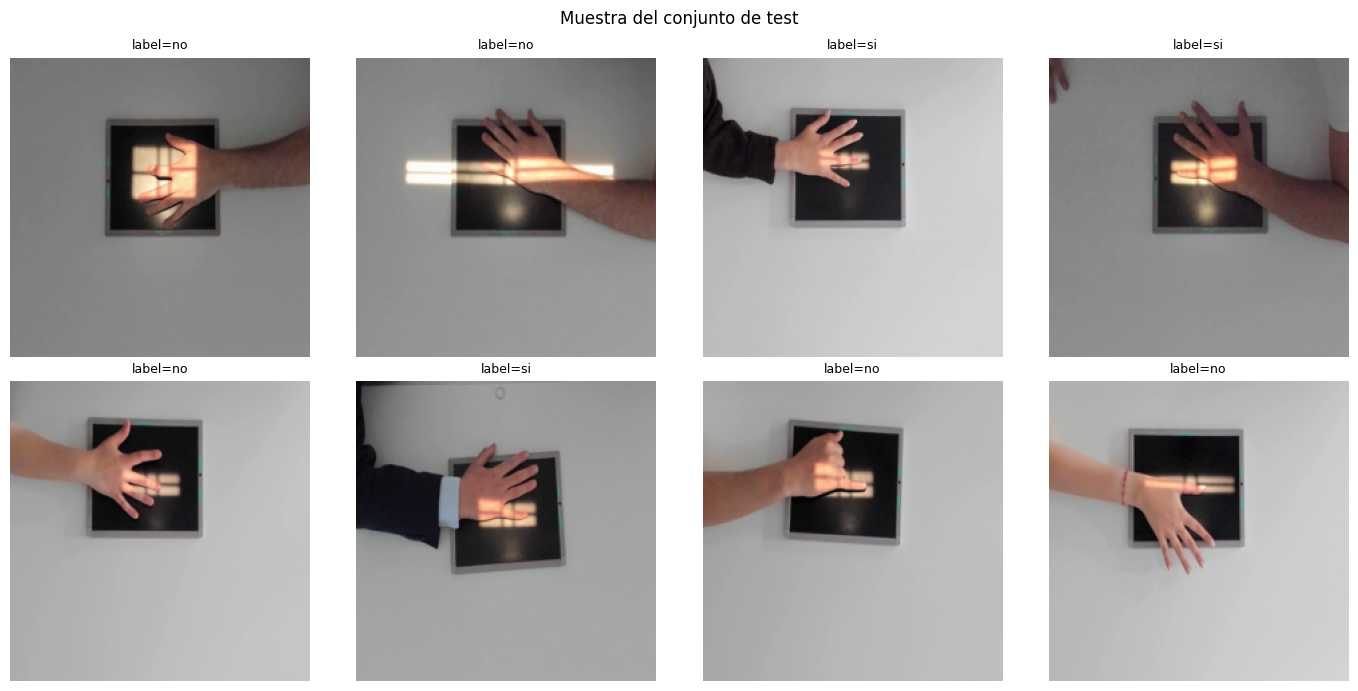

In [152]:
# Muestra aquí varias imágenes del dataset.
def show_samples(df, n=8, title="Ejemplos"):
    sample = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)
    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.ravel()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"]).convert("RGB").resize((224, 224))
        ax.imshow(img)
        ax.set_title(f"label={row['label']}", fontsize=9)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


show_samples(df_test, n=8, title="Muestra del conjunto de test")

## Definir las clases en lenguaje natural

Para un modelo multimodal, `si` y `no` no son suficientes. Necesitáis traducir esas etiquetas a una descripción visual precisa.

Pensad en un checklist como:

- dedo visible;
- dedo centrado o no;
- dedo contenido o no dentro de la zona iluminada;
- presencia de manos extra o escenas ambiguas.

In [153]:
# Describe aquí las clases con lenguaje natural.
label_names = {
    0: "si",
    1: "no",
}

label_descriptions = pd.DataFrame(
    {
        "label": ["si", "no"],
        "description": [
            (
                "postura correcta del dedo: el dedo está visible, centrado en el encuadre, "
                "bien iluminado y completamente contenido dentro de la zona iluminada, "
                "sin otras manos ni elementos que interfieran"
            ),
            (
                "postura incorrecta del dedo: el dedo está cortado, descentrado, mal iluminado, "
                "parcialmente fuera de la zona iluminada, o aparecen otras manos o elementos confusos"
            ),
        ],
    }
)

valid_labels = set(label_descriptions["label"])

label_descriptions

,label,description
0,si,"postura correcta del dedo: el dedo está visible, centrado en el encuadre, bien iluminado y completamente contenido dentro de la zona iluminada, sin otras manos ni elementos que interfieran"
1,no,"postura incorrecta del dedo: el dedo está cortado, descentrado, mal iluminado, parcialmente fuera de la zona iluminada, o aparecen otras manos o elementos confusos"


In [154]:
# Prepara aquí la función o utilidades para enviar imágenes y construir prompts.
def pil_to_data_url(image: Image.Image, image_format: str = "PNG") -> str:
    """Convierte una imagen PIL a data URL en base64."""
    buffer = io.BytesIO()
    image.save(buffer, format=image_format)
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/{image_format.lower()};base64,{encoded}"


def path_to_pil(path: Path, size: int = 224) -> Image.Image:
    """Carga una imagen desde disco, la redimensiona y la convierte a RGB."""
    return Image.open(path).convert("RGB").resize((size, size))


def extract_json_object(text: str) -> dict:
    """Extrae el primer objeto JSON válido de un texto libre."""
    match = re.search(r"\{.*?\}", text, flags=re.DOTALL)
    assert match is not None, f"No se encontró JSON en: {text!r}"
    return json.loads(match.group(0))


SYSTEM_PROMPT = (
    "Eres un asistente experto en clasificación de imágenes de posicionamiento de dedos. "
    "Devuelve solo JSON válido, sin texto adicional."
)


def create_classification_prompt(label_df: pd.DataFrame) -> str:
    """Construye el prompt de clasificación a partir del DataFrame de etiquetas."""
    label_block = "\n".join(
        f"- {row['label']}: {row['description']}"
        for _, row in label_df.iterrows()
    )
    return f"""Clasifica la imagen del dedo en una de estas categorías:

{label_block}

Instrucciones:
- Analiza únicamente la imagen.
- No inventes categorías fuera de las indicadas.
- Si dudas, elige la categoría más probable.
- Devuelve solo un objeto JSON con este formato exacto:
{{"label": "si"}}
""".strip()


print(create_classification_prompt(label_descriptions))

#Tenacity gestiona los reintentos automáticos cuando la API devuelve error de rate-limit o un error transitorio.
#La política es **back-off exponencial**: espera 2 s, luego 4, 8 … hasta 30 s, con un máximo de 5 intentos.

@retry(
    retry=retry_if_exception_type(Exception),
    stop=stop_after_attempt(MAX_RETRIES),
    wait=wait_exponential(multiplier=1, min=WAIT_MIN, max=WAIT_MAX),
    reraise=True,
)
def classify_with_openrouter(
    image: Image.Image,
    client: OpenAI = openrouter_client,
    model: str = DEFAULT_OPENROUTER_MODEL,
    label_df: pd.DataFrame = label_descriptions,
    system_prompt: str = SYSTEM_PROMPT,
) -> str:
    """
    Clasifica una imagen PIL usando un modelo multimodal via OpenRouter.

    Reintentos automáticos gestionados por tenacity:
    - máximo MAX_RETRIES intentos
    - espera exponencial entre WAIT_MIN y WAIT_MAX segundos
    """
    response = client.chat.completions.create(
        model=model,
        temperature=0.0,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": create_classification_prompt(label_df)},
                    {
                        "type": "image_url",
                        "image_url": {"url": pil_to_data_url(image)},
                    },
                ],
            },
        ],
    )

    raw = response.choices[0].message.content.strip()
    parsed = extract_json_object(raw)
    predicted_label = parsed["label"].strip().lower()

    if predicted_label not in valid_labels:
        raise ValueError(f"Etiqueta inesperada: {predicted_label!r}. Respuesta: {raw!r}")

    return predicted_label

Clasifica la imagen del dedo en una de estas categorías:

- si: postura correcta del dedo: el dedo está visible, centrado en el encuadre, bien iluminado y completamente contenido dentro de la zona iluminada, sin otras manos ni elementos que interfieran
- no: postura incorrecta del dedo: el dedo está cortado, descentrado, mal iluminado, parcialmente fuera de la zona iluminada, o aparecen otras manos o elementos confusos

Instrucciones:
- Analiza únicamente la imagen.
- No inventes categorías fuera de las indicadas.
- Si dudas, elige la categoría más probable.
- Devuelve solo un objeto JSON con este formato exacto:
{"label": "si"}


## Probar el prompt con unos pocos ejemplos

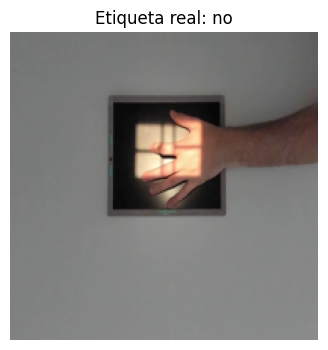

Etiqueta real : no
Predicción    : no
Correcto      : True



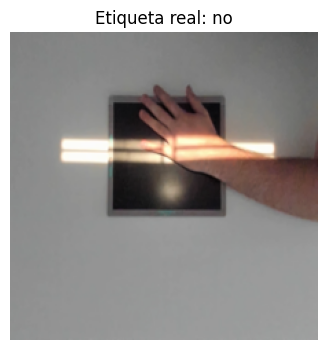

Etiqueta real : no
Predicción    : no
Correcto      : True



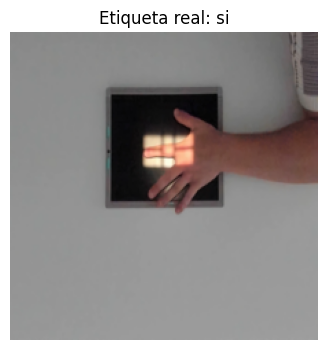

Etiqueta real : si
Predicción    : no
Correcto      : False



In [155]:
# Prueba el prompt con unas pocas imágenes de ejemplo
for i in range(3):
    sample_row = df_test.iloc[i]
    sample_image = path_to_pil(sample_row["path"])
    sample_label = sample_row["label"]

    plt.figure(figsize=(4, 4))
    plt.imshow(sample_image)
    plt.title(f"Etiqueta real: {sample_label}")
    plt.axis("off")
    plt.show()

    prediction = classify_with_openrouter(sample_image)
    print(f"Etiqueta real : {sample_label}")
    print(f"Predicción    : {prediction}")
    print(f"Correcto      : {sample_label == prediction}")
    print()

## Evaluación zero-shot en test

Cuando el prompt os convenza lo suficiente, evaluadlo sobre un subconjunto o sobre todo test.

Calculad al menos:

- accuracy;
- precision;
- recall;
- F1;
- matriz de confusión.

In [156]:
# Ejecuta aquí la evaluación zero-shot.


def evaluate_predictions(y_true, y_pred, labels):
    return {
        "accuracy":         accuracy_score(y_true, y_pred),
        "precision_macro":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":     recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=labels),
    }


def classify_dataset(df, classifier_func, image_column="path", size=224):
    """Clasifica todas las imágenes de un DataFrame y devuelve las predicciones."""
    predictions = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Clasificando imágenes"):
        img = path_to_pil(row[image_column], size=size)
        predictions.append(classifier_func(img))

    return np.array(predictions)

In [157]:
# Subconjunto de test para prompting
prompting_df = df_test.sample(n=min(N_PROMPTING, len(df_test)), random_state=SEED).reset_index(drop=True)

print(f"Imágenes a clasificar: {len(prompting_df)}")
print(prompting_df["label"].value_counts())

Imágenes a clasificar: 17
label
si    9
no    8
Name: count, dtype: int64


In [158]:
y_pred_openrouter = classify_dataset(prompting_df, classify_with_openrouter)

metrics_openrouter = evaluate_predictions(
    prompting_df["label"].to_numpy(),
    y_pred_openrouter,
    labels=["si", "no"],
)

summary_df = pd.DataFrame([
    {
        "method":           "OpenRouter zero-shot",
        "model":            DEFAULT_OPENROUTER_MODEL,
        "accuracy":         round(metrics_openrouter["accuracy"], 3),
        "precision_macro":  round(metrics_openrouter["precision_macro"], 3),
        "recall_macro":     round(metrics_openrouter["recall_macro"], 3),
        "f1_macro":         round(metrics_openrouter["f1_macro"], 3),
    }
])

summary_df

Clasificando imágenes:   0%|          | 0/17 [00:00<?, ?it/s]

,method,model,accuracy,precision_macro,recall_macro,f1_macro
0,OpenRouter zero-shot,~google/gemini-flash-latest,0.471,0.235,0.5,0.32


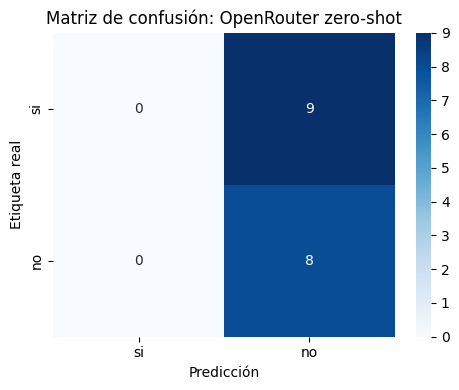

In [159]:
# Resume aquí las métricas y la matriz de confusión.
plt.figure(figsize=(5, 4))
sns.heatmap(
    metrics_openrouter["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["si", "no"],
    yticklabels=["si", "no"],
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title(f"Matriz de confusión: OpenRouter zero-shot")
plt.tight_layout()
plt.show()

## Analizar respuestas y errores del prompting

Mirad ejemplos donde el modelo falle y tratad de identificar:

- errores por prompt ambiguo;
- errores por imagen difícil;
- errores por escena confusa;
- errores por usar la imagen original en lugar de un recorte.

In [160]:
# Inspecciona aquí varios errores del prompting.
analysis_df = prompting_df[["path", "label"]].copy()
analysis_df["prediction"] = y_pred_openrouter
analysis_df["is_correct"] = analysis_df["label"] == analysis_df["prediction"]

print(f"Correctos : {analysis_df['is_correct'].sum()}")
print(f"Errores   : {(~analysis_df['is_correct']).sum()}")

mistakes_df = analysis_df[~analysis_df["is_correct"]].reset_index(drop=True)
mistakes_df[["path", "label", "prediction"]]

Correctos : 8
Errores   : 9


,path,label,prediction
0,/home/manel31/Escritorio/cursoIA/dedo/si/img_1777028530747.png,si,no
1,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863516809.png,si,no
2,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776940961519.png,si,no
3,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863881713.png,si,no
4,/home/manel31/Escritorio/cursoIA/dedo/si/img_1777027197915.png,si,no
5,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776864651121.png,si,no
6,/home/manel31/Escritorio/cursoIA/dedo/si/img_1777028264615.png,si,no
7,/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863898155.png,si,no
8,/home/manel31/Escritorio/cursoIA/dedo/si/img_1777026555963.png,si,no


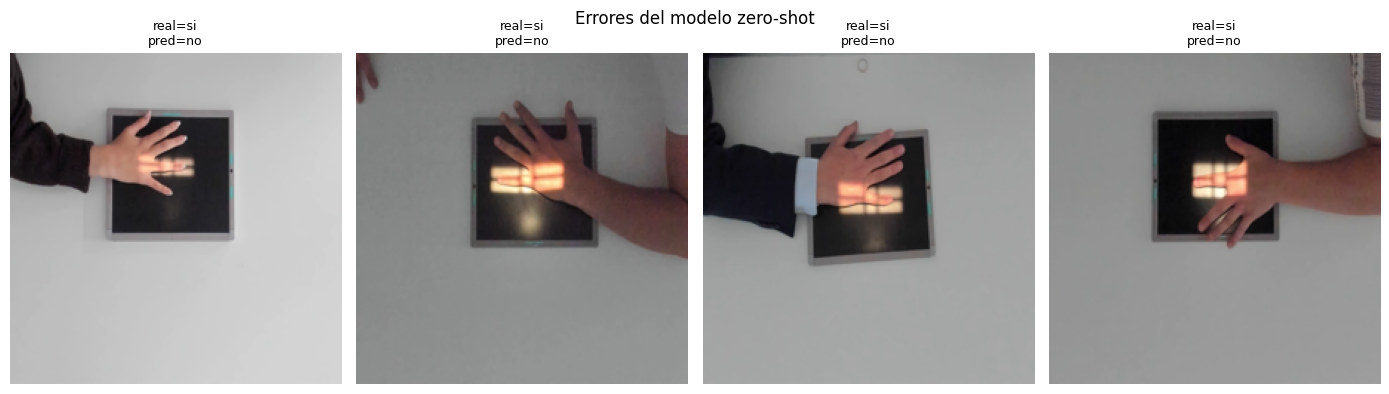

In [161]:
n_show = min(4, len(mistakes_df))

if n_show == 0:
    print("¡Sin errores en este subconjunto!")
else:
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 3.5, 4))
    if n_show == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, mistakes_df.iloc[:n_show].iterrows()):
        img = path_to_pil(row["path"])
        ax.imshow(img)
        ax.set_title(f"real={row['label']}\npred={row['prediction']}", fontsize=9)
        ax.axis("off")

    plt.suptitle("Errores del modelo zero-shot", fontsize=12)
    plt.tight_layout()
    plt.show()

## Extensión opcional: few-shot

Si llegáis a esta parte, añadid una o dos imágenes de referencia al prompt:

- una correcta;
- una incorrecta.

Luego comparad si mejora respecto al zero-shot puro.

In [162]:
# Añade aquí una variante few-shot si quieres probarla.

## Extensión opcional: embeddings visuales

La segunda vía del día consiste en reutilizar un encoder visual preentrenado.

Idea general:

1. convertir cada imagen en un vector de embedding;
2. entrenar un clasificador sencillo encima;
3. evaluar ese clasificador en test.

Podéis usar un encoder tipo DINOv2, DINOv3 u otro backbone visual disponible.

In [163]:
# Carga aquí un encoder visual preentrenado.

In [164]:
# Extrae aquí embeddings para train y test.

In [165]:
# Entrena aquí un clasificador simple sobre embeddings.

In [166]:
# Evalúa aquí el clasificador de embeddings.

## Comparar enfoques

Si habéis completado más de una variante, comparad:

- zero-shot frente a few-shot;
- prompting frente a embeddings;
- imagen completa frente a recorte del panel.

In [167]:
# Resume aquí la comparación entre enfoques.

## Conclusiones

Escribid aquí unas conclusiones breves:

- qué enfoque habéis completado;
- qué ventajas tiene;
- qué límites habéis encontrado;